In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point



training_df = pd.read_csv("water_quality_training_dataset.csv")
testing_df = pd.read_csv("submission_template.csv")

In [2]:
training_df


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0
...,...,...,...,...,...,...
9314,-27.527500,30.858056,23-12-2015,38.900,134.0,20.0
9315,-26.861111,28.884722,23-12-2015,115.800,388.0,20.0
9316,-26.984722,26.632278,23-12-2015,104.874,835.0,148.0
9317,-27.935000,26.126667,23-12-2015,128.000,305.0,28.0


In [6]:
gdf = gpd.GeoDataFrame(
    training_df, geometry=gpd.points_from_xy(training_df["Longitude"],training_df["Latitude"], crs="EPSG:4326")
)
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

NameError: name 'world' is not defined

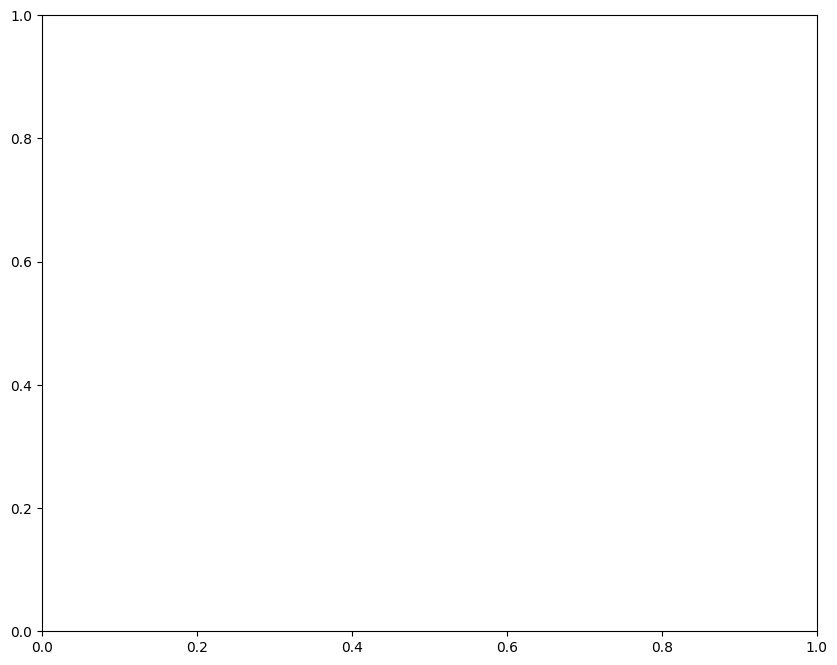

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
world.boundary.plot(ax=ax) # Plot world map boundaries
gdf.plot(ax=ax, color='red', marker='o', markersize=20) # Plot the coordinates as red points

# Set plot limits to focus on a specific region (e.g., South America)
ax.set_xlim([-85, -30])
ax.set_ylim([-60, 15])

plt.title("Coordinates Plotted on a World Map")
plt.show()